# Анализ и обработка датасета

In [42]:
import sys
sys.path.append("..")
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random
from datasets import DatasetDict
from src.data import load_rultaker, PROJECT_ROOT

sns.set_style("whitegrid")
CACHE_DIR = os.path.join(PROJECT_ROOT, "data/processed")
os.makedirs(CACHE_DIR, exist_ok=True)

In [43]:
from src.data import prepare_example

RuleTaker - это синтетический датасет, разработанный AI2 (Allen Institute for AI) и представленный в работе "Transformers as Soft Reasoners over Language"

Датасет создан для тестирования трансформеров на задачах интерпретируемости (цель: проверить, могут ли трансформеры выполнять многошаговые логические рассуждения на естественном языке)

В датасете есть 2 версии
- Problog
    - Содержит формальные логические программы, которые может выполнить движок Problog, чтобы сгенерировать абсолютно точные метки (gold labels) для каждого примера (точно известно, каким должен быть правильный ответ, что важно для объективной оценки)
- Original
    - Содержит те же правила, но в более свободном, "естественно-языковом" формате, близком к разговорному английскому

Также датасеты делятся по глубине:
- Depth-0: Утверждение напрямую следует из факта (базовый случай)
- Depth-1: Для вывода нужен один шаг (например, из посылки X -> Y выводится Y)
- Depth-2: Для вывода нужны два последовательных шага (например, из A -> B и B -> C выводится C)
- Depth-3: Примеры, для которых требуются цепочки рассуждений из трёх логических шагов для получения ответа
- Depth-5: Ещё более сложные примеры с цепочками рассуждений из пяти шагов
- Depth-3ext: "Расширенный" (extended) depth-3. Он содержит примеры с цепочками разной длины (включая более короткие, из depth-0, depth-1, depth-2) в дополнение к трёхшаговым

In [44]:
def ds_combined(ds_train, ds_dev, ds_test):
    # Объединение подвыборок
    return [("train", ds_train), ("dev", ds_dev), ("test", ds_test)]

In [45]:
def ds_global_max(datasets):
    # Сбор глобального максимума
    all_max = 0
    for _, ds in datasets:
        labels = [ex["theory_assertion_instance"]["label"] for ex in ds]
        vc = pd.Series(labels).value_counts()
        all_max = max(all_max, vc.max())
    return all_max

In [46]:
def label_distribution(datasets, ds_name, ds_global_max):
    # Создание графиков распределения меток в подвыборках
    fig, axes = plt.subplots(1, 3, figsize=(9, 4))

    colors_bar = ["#2ecc71", "#e74c3c"]  # зелёный для True, красный для False

    for ax, (split_name, ds) in zip(axes, datasets):
        # Извлекаем метки
        labels = [ex["theory_assertion_instance"]["label"] for ex in ds]
        df_counts = pd.DataFrame({"label": labels})
        counts = df_counts["label"].value_counts().reset_index()
        counts.columns = ["label", "count"]
        counts = counts.sort_values("label", ascending=False)  # True первым

        # График
        sns.barplot(data=counts, x="label", y="count",
                    palette=colors_bar, hue="label", edgecolor='black', linewidth=0.8, ax=ax, legend=False)

        # Оси и подписи
        ax.set_title(f"{split_name.capitalize()} ({ds_name})", fontsize=12)
        ax.set_xlabel("Метка (True/False)", fontsize=10)
        ax.set_ylabel("Количество", fontsize=10)
        ax.set_ylim(0, ds_global_max * 1.05)

        # Подписи значений на столбцах
        for i, (bar, val) in enumerate(zip(ax.patches, counts["count"])):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ds_global_max*0.01,
                    str(val), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

In [47]:
def compute_text_stats(ds, name):
    # Подсчет статистик в подвыборке
    n_statements = []
    n_chars = []
    for ex in ds:
        theory = " ".join(ex["english"]["theory_statements"])
        assertion = ex["english"]["assertion_statement"]
        full = theory + " " + assertion
        n_statements.append(len(ex["english"]["theory_statements"]))
        n_chars.append(len(full))
    print(f"{name}: среднее число утверждений в теории = {np.mean(n_statements):.2f} +/- {np.std(n_statements):.2f}")
    print(f"{name}: средняя длина текста (символов) = {np.mean(n_chars):.2f} +/- {np.std(n_chars):.2f}")
    return n_statements, n_chars

In [48]:
def complexity_distribution(stats_train, stats_dev, stats_test, VARIANT):
    # Создание графиков распределения сложности и длины текстов в подвыборках
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(stats_train[0], bins=20, alpha=0.7, label='train', edgecolor='black')
    axes[0].hist(stats_dev[0], bins=20, alpha=0.7, label='dev', edgecolor='black')
    axes[0].hist(stats_test[0], bins=20, alpha=0.7, label='test', edgecolor='black')
    axes[0].set_title(f"{VARIANT} - распределение сложности")
    axes[0].set_xlabel("Количество утверждений в теории", fontsize=11)  # Number of statements in theory, сложность
    axes[0].set_ylabel("Частота", fontsize=11)
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)

    axes[1].hist(stats_train[1], bins=20, alpha=0.7, label='train', edgecolor='black')
    axes[1].hist(stats_dev[1], bins=20, alpha=0.7, label='dev', edgecolor='black')
    axes[1].hist(stats_test[1], bins=20, alpha=0.7, label='test', edgecolor='black')
    axes[1].set_title(f"{VARIANT} - распределение длины")
    axes[1].set_xlabel("Длина текста (символов)", fontsize=11)
    axes[1].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [49]:
def get_n_examples(n, ds_sample):
    # Несколько (n) случайных примеров с метками
    indices = random.sample(range(len(ds_sample)), min(n, len(ds_sample)))
    for i in indices:
        ex = ds_sample[i]
        print(f"ID: {ex['id']}")
        print("Theory statements:")
        for stmt in ex["english"]["theory_statements"][:3]:
            print("  ", stmt)
        if len(ex["english"]["theory_statements"]) > 3:
            print("  ...")
        print(f"Assertion: {ex['english']['assertion_statement']}")
        print(f"Label: {ex['theory_assertion_instance']['label']}")
        print("-" * 50)

In [50]:
def save_ds_stats(ds_train, ds_dev, ds_test, VARIANT):
    # Сохранение статистик в отдельный файл
    stats_file = os.path.join(CACHE_DIR, f"ruletaker_{VARIANT}_stats.txt")
    with open(stats_file, "w") as f:
        f.write(f"RuleTaker {VARIANT} statistics\n")
        f.write(f"Train size: {len(ds_train)}\n")
        f.write(f"Dev size:   {len(ds_dev)}\n")
        f.write(f"Test size:  {len(ds_test)}\n")
        f.write(f"Positive label ratio (train): {sum(ds_train['label'])/len(ds_train):.3f}\n")
        f.write(f"Positive label ratio (dev):   {sum(ds_dev['label'])/len(ds_dev):.3f}\n")
        f.write(f"Positive label ratio (test):  {sum(ds_test['label'])/len(ds_test):.3f}\n")

In [51]:
def save_ds_cached(ds_train, ds_dev, ds_test, suffix):
    # Сохранение обработанного датасета
    dataset_dict = DatasetDict({
        "train": ds_train,
        "dev": ds_dev,
        "test": ds_test
    })
    full_cache_path = os.path.join(CACHE_DIR, f"ruletaker_{suffix}")
    dataset_dict.save_to_disk(full_cache_path)
    print(f"Кэш сохранён в {full_cache_path}")

## Датасет depth-1

In [11]:
# ВЫБОР ВАРИАНТА ДАТАСЕТА
VARIANT = "depth-1"

### Импорт данных

In [12]:
ds_depth1_train = load_rultaker(split="train", variant=VARIANT)
ds_depth1_dev   = load_rultaker(split="dev",   variant=VARIANT)
ds_depth1_test  = load_rultaker(split="test",  variant=VARIANT)

In [13]:
print(f"Train size: {len(ds_depth1_train)}")
print(f"Dev size:   {len(ds_depth1_dev)}")
print(f"Test size:  {len(ds_depth1_test)}")

Train size: 61699
Dev size:   8870
Test size:  17788


### EDA

In [14]:
datasets_depth1 = ds_combined(ds_depth1_train, ds_depth1_dev, ds_depth1_test)

In [15]:
# Вычисляем длину самой объемной подвыборки (для визуализации в одном масштабе)
all_max_depth1 = ds_global_max(datasets_depth1)

In [16]:
all_max_depth1

30947

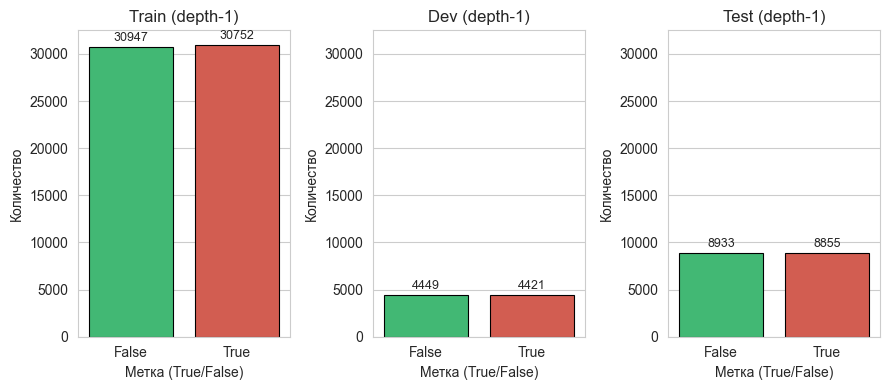

In [17]:
label_distribution(datasets_depth1, VARIANT, all_max_depth1)

В RuleTaker каждый пример состоит из 2х частей: теории и умозаключения. Предполагается, что тестируемая на датасете модель должна предсказать, следует ли умозаключение из теории

In [18]:
stats_depth1_train = compute_text_stats(ds_depth1_train, f"{VARIANT} train")
stats_depth1_dev   = compute_text_stats(ds_depth1_dev, f"{VARIANT} dev")
stats_depth1_test  = compute_text_stats(ds_depth1_test, f"{VARIANT} test")

depth-1 train: среднее число утверждений в теории = 12.87 +/- 5.55
depth-1 train: средняя длина текста (символов) = 408.84 +/- 213.72
depth-1 dev: среднее число утверждений в теории = 12.79 +/- 5.57
depth-1 dev: средняя длина текста (символов) = 408.47 +/- 213.40
depth-1 test: среднее число утверждений в теории = 12.69 +/- 5.54
depth-1 test: средняя длина текста (символов) = 407.76 +/- 212.54


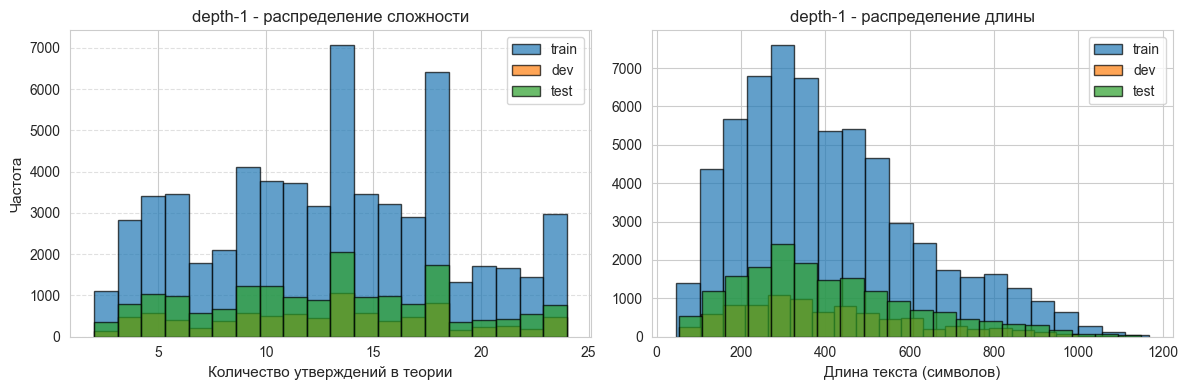

In [19]:
complexity_distribution(stats_depth1_train, stats_depth1_dev, stats_depth1_test, VARIANT)

In [20]:
get_n_examples(3, ds_depth1_train)

ID: RelNoneg-D1-1276_7
Theory statements:
   The bald eagle sees the bear.
   The bear visits the rabbit.
   The dog visits the bear.
  ...
Assertion: The bald eagle is not big.
Label: True
--------------------------------------------------
ID: AttNeg-D1-13_3
Theory statements:
   Erin is round.
   If something is round and not young then it is cold.
Assertion: Erin is cold.
Label: True
--------------------------------------------------
ID: RelNoneg-D1-1361_1
Theory statements:
   The bear likes the dog.
   The dog needs the bear.
   The dog visits the bear.
  ...
Assertion: The bear likes the dog.
Label: True
--------------------------------------------------


In [21]:
ds_depth1_train = ds_depth1_train.map(prepare_example, remove_columns=ds_depth1_train.column_names)
ds_depth1_dev   = ds_depth1_dev.map(prepare_example, remove_columns=ds_depth1_dev.column_names)
ds_depth1_test  = ds_depth1_test.map(prepare_example, remove_columns=ds_depth1_test.column_names)

In [22]:
# Пример после предобработки
ds_depth1_train[0]

{'id': 'AttNeg-D1-1343_1',
 'text': 'Anne is quiet. Anne is not young. Bob is kind. Bob is young. Dave is rough. Dave is round. Dave is smart. Dave is not young. Fiona is quiet. Fiona is not round. Kind, young things are not smart. Bob is kind.',
 'label': True,
 'theory': 'Anne is quiet. Anne is not young. Bob is kind. Bob is young. Dave is rough. Dave is round. Dave is smart. Dave is not young. Fiona is quiet. Fiona is not round. Kind, young things are not smart.',
 'assertion': 'Bob is kind.',
 'min_proof_depth': -1}

### Кэширование

In [23]:
save_ds_stats(ds_depth1_train, ds_depth1_dev, ds_depth1_test, VARIANT)

In [24]:
save_ds_cached(ds_depth1_train, ds_depth1_dev, ds_depth1_test, VARIANT)

Saving the dataset (0/1 shards):   0%|          | 0/61699 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8870 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/17788 [00:00<?, ? examples/s]

Кэш сохранён в C:\MyPythonProjects\mephi_diss\data/processed\ruletaker_depth-1


In [25]:
# Создание усеченных версий
small_depth1_train = ds_depth1_train.select(range(min(2000, len(ds_depth1_train))))
small_depth1_dev   = ds_depth1_dev.select(range(min(500, len(ds_depth1_dev))))
small_depth1_test  = ds_depth1_test.select(range(min(500, len(ds_depth1_test))))

In [26]:
save_ds_cached(small_depth1_train, small_depth1_dev, small_depth1_test, f"{VARIANT}_small")

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Кэш сохранён в C:\MyPythonProjects\mephi_diss\data/processed\ruletaker_depth-1_small


## Датасет depth-2

In [27]:
# ВЫБОР ВАРИАНТА ДАТАСЕТА
VARIANT = "depth-2"

### Импорт данных

In [28]:
ds_depth2_train = load_rultaker(split="train", variant=VARIANT)
ds_depth2_dev   = load_rultaker(split="dev",   variant=VARIANT)
ds_depth2_test  = load_rultaker(split="test",  variant=VARIANT)

In [29]:
print(f"Train size: {len(ds_depth2_train)}")
print(f"Dev size:   {len(ds_depth2_dev)}")
print(f"Test size:  {len(ds_depth2_test)}")

Train size: 62331
Dev size:   8906
Test size:  17741


### EDA

In [30]:
datasets_depth2 = ds_combined(ds_depth2_train, ds_depth2_dev, ds_depth2_test)
# Вычисляем длину самой объемной подвыборки (для визуализации в одном масштабе)
all_max_depth2 = ds_global_max(datasets_depth2)

In [31]:
all_max_depth2

31375

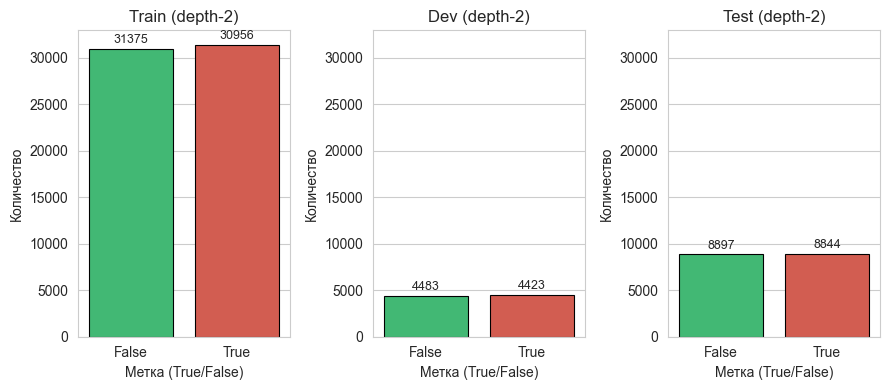

In [32]:
label_distribution(datasets_depth2, VARIANT, all_max_depth2)

In [33]:
stats_depth2_train = compute_text_stats(ds_depth2_train, f"{VARIANT} train")
stats_depth2_dev   = compute_text_stats(ds_depth2_dev, f"{VARIANT} dev")
stats_depth2_test  = compute_text_stats(ds_depth2_test, f"{VARIANT} test")

depth-2 train: среднее число утверждений в теории = 13.56 +/- 5.45
depth-2 train: средняя длина текста (символов) = 452.03 +/- 216.85
depth-2 dev: среднее число утверждений в теории = 13.37 +/- 5.53
depth-2 dev: средняя длина текста (символов) = 446.92 +/- 223.23
depth-2 test: среднее число утверждений в теории = 13.51 +/- 5.36
depth-2 test: средняя длина текста (символов) = 453.51 +/- 213.70


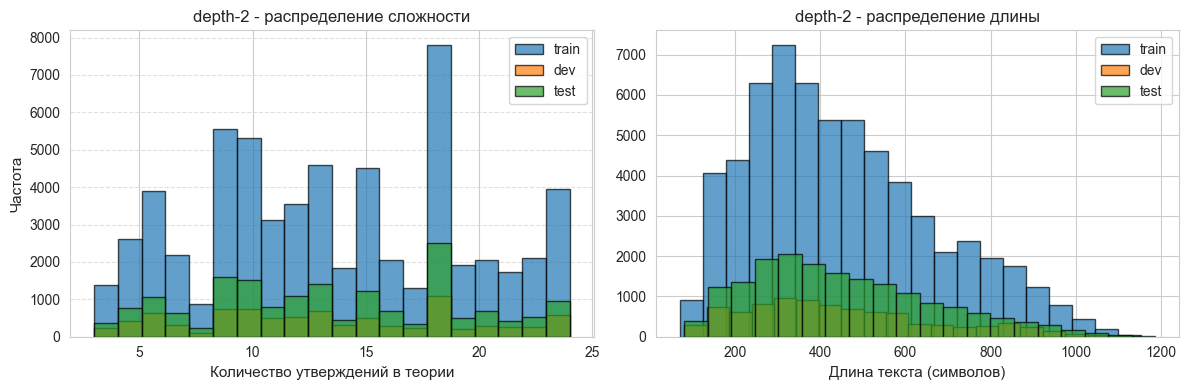

In [34]:
complexity_distribution(stats_depth2_train, stats_depth2_dev, stats_depth2_test, VARIANT)

In [35]:
get_n_examples(3, ds_depth2_train)

ID: AttNoneg-D2-959_5
Theory statements:
   Fiona is big.
   Fiona is blue.
   Fiona is kind.
  ...
Assertion: Fiona is smart.
Label: True
--------------------------------------------------
ID: AttNoneg-D2-1121_6
Theory statements:
   Dave is cold.
   Dave is green.
   Dave is quiet.
  ...
Assertion: Dave is not round.
Label: False
--------------------------------------------------
ID: RelNoneg-D2-1488_1
Theory statements:
   The bear sees the cow.
   The bear sees the mouse.
   The cow chases the bear.
  ...
Assertion: The cow sees the rabbit.
Label: True
--------------------------------------------------


In [36]:
ds_depth2_train = ds_depth2_train.map(prepare_example, remove_columns=ds_depth2_train.column_names)
ds_depth2_dev   = ds_depth2_dev.map(prepare_example, remove_columns=ds_depth2_dev.column_names)
ds_depth2_test  = ds_depth2_test.map(prepare_example, remove_columns=ds_depth2_test.column_names)

Map:   0%|          | 0/62331 [00:00<?, ? examples/s]

Map:   0%|          | 0/8906 [00:00<?, ? examples/s]

Map:   0%|          | 0/17741 [00:00<?, ? examples/s]

In [37]:
# Пример после предобработки
ds_depth2_train[0]

{'id': 'RelNeg-D2-1742_1',
 'text': 'The bald eagle is nice. The squirrel visits the bald eagle. If something needs the bald eagle and it is not cold then it visits the bald eagle. If something is nice and it does not eat the squirrel then the squirrel eats the bald eagle. Green things are rough. If something eats the squirrel and it needs the bald eagle then it does not need the squirrel. If something eats the squirrel then the squirrel needs the bald eagle. If the bald eagle eats the squirrel and something does not eat the bald eagle then the bald eagle visits the squirrel. If the squirrel eats the bald eagle and the bald eagle does not visit the squirrel then the bald eagle needs the squirrel. If the squirrel is rough and the bald eagle does not need the squirrel then the squirrel needs the bald eagle. The squirrel visits the bald eagle.',
 'label': True,
 'theory': 'The bald eagle is nice. The squirrel visits the bald eagle. If something needs the bald eagle and it is not cold then

### Кэширование

In [38]:
save_ds_stats(ds_depth2_train, ds_depth2_dev, ds_depth2_test, VARIANT)

In [39]:
save_ds_cached(ds_depth2_train, ds_depth2_dev, ds_depth2_test, VARIANT)

Saving the dataset (0/1 shards):   0%|          | 0/62331 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8906 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/17741 [00:00<?, ? examples/s]

Кэш сохранён в C:\MyPythonProjects\mephi_diss\data/processed\ruletaker_depth-2


In [40]:
# Создание усеченных версий
small_depth2_train = ds_depth2_train.select(range(min(2000, len(ds_depth2_train))))
small_depth2_dev   = ds_depth2_dev.select(range(min(500, len(ds_depth2_dev))))
small_depth2_test  = ds_depth2_test.select(range(min(500, len(ds_depth2_test))))

In [41]:
save_ds_cached(small_depth2_train, small_depth2_dev, small_depth2_test, f"{VARIANT}_small")

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Кэш сохранён в C:\MyPythonProjects\mephi_diss\data/processed\ruletaker_depth-2_small


## Датасет depth-0

In [52]:
# ВЫБОР ВАРИАНТА ДАТАСЕТА
VARIANT = "depth-0"

### Импорт данных

In [53]:
ds_depth0_train = load_rultaker(split="train", variant=VARIANT)
ds_depth0_dev   = load_rultaker(split="dev",   variant=VARIANT)
ds_depth0_test  = load_rultaker(split="test",  variant=VARIANT)

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [54]:
print(f"Train size: {len(ds_depth0_train)}")
print(f"Dev size:   {len(ds_depth0_dev)}")
print(f"Test size:  {len(ds_depth0_test)}")

Train size: 60557
Dev size:   8718
Test size:  17347


### EDA

In [55]:
datasets_depth0 = ds_combined(ds_depth0_train, ds_depth0_dev, ds_depth0_test)
# Вычисляем длину самой объемной подвыборки (для визуализации в одном масштабе)
all_max_depth0 = ds_global_max(datasets_depth0)

In [56]:
all_max_depth0

31190

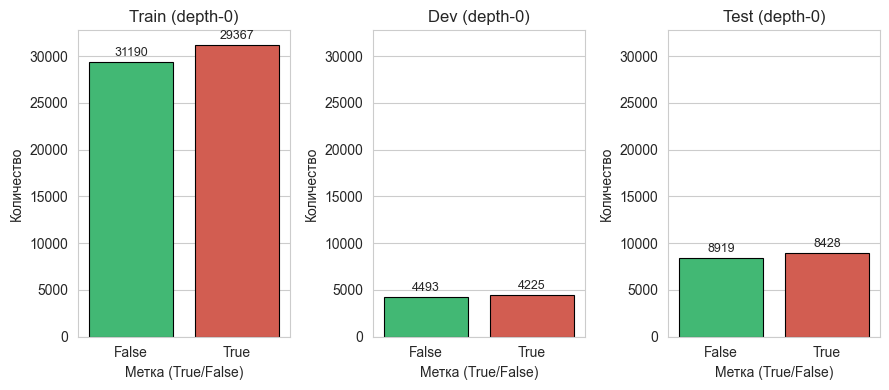

In [57]:
label_distribution(datasets_depth0, VARIANT, all_max_depth0)

In [58]:
stats_depth0_train = compute_text_stats(ds_depth0_train, f"{VARIANT} train")
stats_depth0_dev   = compute_text_stats(ds_depth0_dev, f"{VARIANT} dev")
stats_depth0_test  = compute_text_stats(ds_depth0_test, f"{VARIANT} test")

depth-0 train: среднее число утверждений в теории = 12.61 +/- 5.44
depth-0 train: средняя длина текста (символов) = 394.30 +/- 207.52
depth-0 dev: среднее число утверждений в теории = 12.65 +/- 5.40
depth-0 dev: средняя длина текста (символов) = 397.42 +/- 208.37
depth-0 test: среднее число утверждений в теории = 12.75 +/- 5.41
depth-0 test: средняя длина текста (символов) = 398.24 +/- 207.23


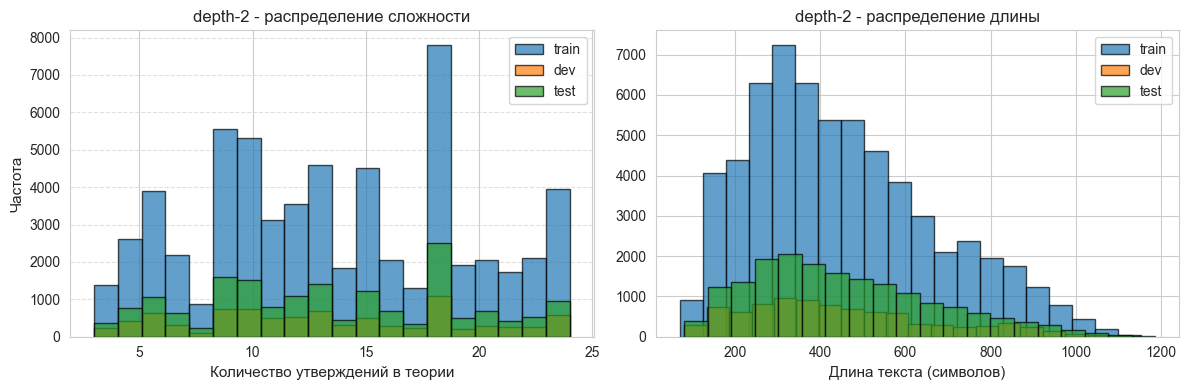

In [ ]:
complexity_distribution(stats_depth0_train, stats_depth0_dev, stats_depth0_test, VARIANT)

In [59]:
get_n_examples(3, ds_depth0_train)

ID: RelNoneg-D0-4999_3
Theory statements:
   The bald eagle is red.
   The cat is kind.
   The cat is young.
  ...
Assertion: The bald eagle does not visit the bald eagle.
Label: True
--------------------------------------------------
ID: AttNoneg-D0-1587_2
Theory statements:
   Dave is cold.
   If Dave is white then Dave is round.
   If someone is round then they are cold.
Assertion: Dave is not cold.
Label: False
--------------------------------------------------
ID: RelNeg-D0-2512_3
Theory statements:
   The bear does not eat the lion.
   The bear is round.
   The bear is young.
  ...
Assertion: The lion is not red.
Label: True
--------------------------------------------------


In [60]:
ds_depth0_train = ds_depth0_train.map(prepare_example, remove_columns=ds_depth0_train.column_names)
ds_depth0_dev   = ds_depth0_dev.map(prepare_example, remove_columns=ds_depth0_dev.column_names)
ds_depth0_test  = ds_depth0_test.map(prepare_example, remove_columns=ds_depth0_test.column_names)

Map:   0%|          | 0/60557 [00:00<?, ? examples/s]

Map:   0%|          | 0/8718 [00:00<?, ? examples/s]

Map:   0%|          | 0/17347 [00:00<?, ? examples/s]

In [61]:
# Пример после предобработки
ds_depth0_train[0]

{'id': 'AttNoneg-D0-4788_1',
 'text': 'Anne is blue. Anne is rough. Anne is young. All young people are cold. If someone is rough and nice then they are green. Rough people are young. If Anne is green then Anne is blue. If someone is rough and furry then they are blue. Cold people are rough. Anne is rough.',
 'label': True,
 'theory': 'Anne is blue. Anne is rough. Anne is young. All young people are cold. If someone is rough and nice then they are green. Rough people are young. If Anne is green then Anne is blue. If someone is rough and furry then they are blue. Cold people are rough.',
 'assertion': 'Anne is rough.',
 'min_proof_depth': -1}

### Кэширование

In [62]:
save_ds_stats(ds_depth0_train, ds_depth0_dev, ds_depth0_test, VARIANT)

In [63]:
save_ds_cached(ds_depth0_train, ds_depth0_dev, ds_depth0_test, VARIANT)

Saving the dataset (0/1 shards):   0%|          | 0/60557 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8718 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/17347 [00:00<?, ? examples/s]

Кэш сохранён в C:\MyPythonProjects\mephi_diss\data/processed\ruletaker_depth-0


In [64]:
# Создание усеченных версий
small_depth0_train = ds_depth0_train.select(range(min(2000, len(ds_depth0_train))))
small_depth0_dev   = ds_depth0_dev.select(range(min(500, len(ds_depth0_dev))))
small_depth0_test  = ds_depth0_test.select(range(min(500, len(ds_depth0_test))))

In [65]:
save_ds_cached(small_depth0_train, small_depth0_dev, small_depth0_test, f"{VARIANT}_small")

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Кэш сохранён в C:\MyPythonProjects\mephi_diss\data/processed\ruletaker_depth-0_small
